# Chapter 2, Applied Exercise 8 — The `College` Data Set
Christopher Leiby

September 16, 2026

Data201 Week 2 Assignment


### (a) Read the data into Python with `pd.read_csv()`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

college = pd.read_csv('College.csv')
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### (b) Fix the index

In [2]:
college2 = pd.read_csv('College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')
college = college3
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### (c) Numerical summary with `describe()`

In [3]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


### (d) Scatterplot matrix of `Top10perc`, `Apps`, `Enroll`

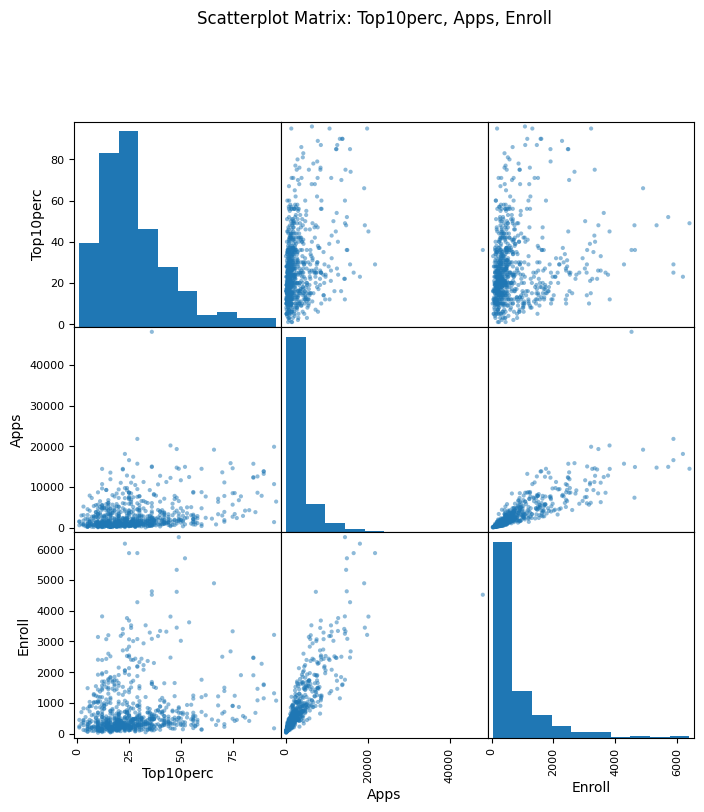

In [4]:
pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']],
                            figsize=(8, 8));
plt.suptitle('Scatterplot Matrix: Top10perc, Apps, Enroll', y=1.02)
plt.show()

### (e) Side-by-side boxplots of `Outstate` versus `Private`

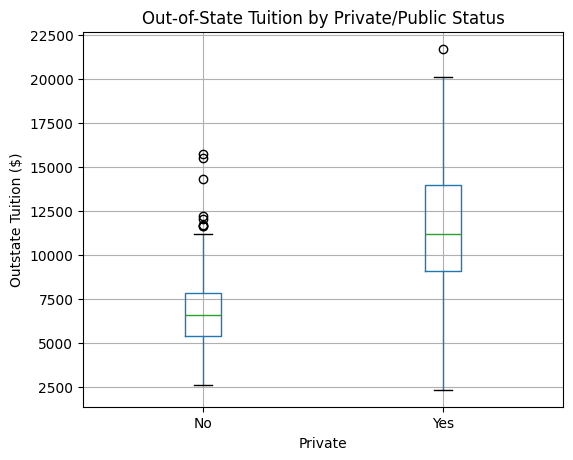

In [5]:
college.boxplot(column='Outstate', by='Private', figsize=(6, 5))
plt.title('Out-of-State Tuition by Private/Public Status')
plt.suptitle('')
plt.ylabel('Outstate Tuition ($)')
plt.show()

### (f) Create the `Elite` variable

Bin `Top10perc` into two groups: `Elite = 'Yes'` if more than 50% of a
college's new students came from the top 10% of their high school class,
otherwise `'No'`.

In [6]:
college['Elite'] = pd.cut(college['Top10perc'],
                          [0, 50, 100],
                          labels=['No', 'Yes'])
college['Elite'].value_counts()

Elite
No     699
Yes     78
Name: count, dtype: int64

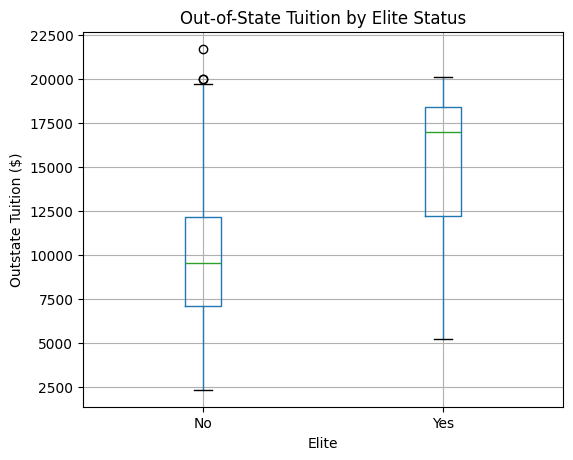

In [7]:
college.boxplot(column='Outstate', by='Elite', figsize=(6, 5))
plt.title('Out-of-State Tuition by Elite Status')
plt.suptitle('')
plt.ylabel('Outstate Tuition ($)')
plt.show()

### (g) Histograms with differing bin counts

`plt.subplots(2, 2)` divides the figure into a 2x2 grid so four histograms
(each with a different number of bins) can be shown at once.

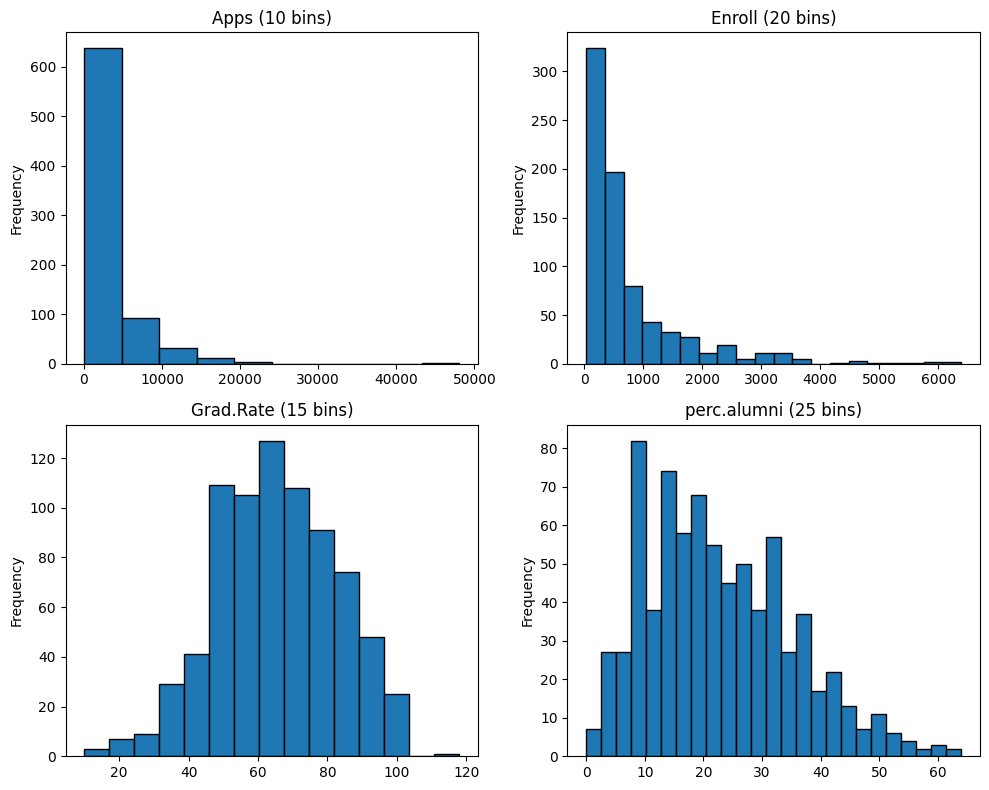

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

college['Apps'].plot.hist(ax=axes[0, 0], bins=10, edgecolor='black')
axes[0, 0].set_title('Apps (10 bins)')

college['Enroll'].plot.hist(ax=axes[0, 1], bins=20, edgecolor='black')
axes[0, 1].set_title('Enroll (20 bins)')

college['Grad.Rate'].plot.hist(ax=axes[1, 0], bins=15, edgecolor='black')
axes[1, 0].set_title('Grad.Rate (15 bins)')

college['perc.alumni'].plot.hist(ax=axes[1, 1], bins=25, edgecolor='black')
axes[1, 1].set_title('perc.alumni (25 bins)')

plt.tight_layout()
plt.show()

### (h) Continue exploring the data

A few more angles: which variables correlate most strongly with graduation
rate, how expenditure per student relates to Outstate tuition, and where the
`Grad.Rate` outlier(s) are.

In [9]:
correlations = college.select_dtypes(include=[np.number]).corr()['Grad.Rate'].sort_values(ascending=False)
correlations

Grad.Rate      1.000000
Outstate       0.571290
Top10perc      0.494989
perc.alumni    0.490898
Top25perc      0.477281
Room.Board     0.424942
Expend         0.390343
PhD            0.305038
Terminal       0.289527
Apps           0.146755
Accept         0.067313
Books          0.001061
Enroll        -0.022341
F.Undergrad   -0.078773
P.Undergrad   -0.257001
Personal      -0.269344
S.F.Ratio     -0.306710
Name: Grad.Rate, dtype: float64

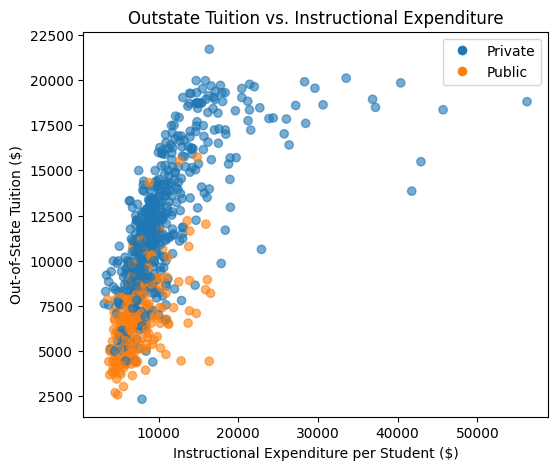

In [10]:
plt.figure(figsize=(6, 5))
colors = college['Private'].map({'Yes': 'tab:blue', 'No': 'tab:orange'})
plt.scatter(college['Expend'], college['Outstate'], c=colors, alpha=0.6)
plt.xlabel('Instructional Expenditure per Student ($)')
plt.ylabel('Out-of-State Tuition ($)')
plt.title('Outstate Tuition vs. Instructional Expenditure')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', label='Private', markersize=8),
                     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', label='Public', markersize=8)])
plt.show()

In [11]:
# Colleges with a graduation rate above 100% (a known data-entry artifact in this dataset)
college[college['Grad.Rate'] > 100]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Elite
College,,,,,,,,,,,,,,,,,,,
Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22,47,14.3,20,7697,118,No


---

# Chapter 2, Applied Exercise 9 — The `Auto` Data Set

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

auto = pd.read_csv('Auto.csv')
auto['horsepower'] = pd.to_numeric(auto['horsepower'], errors='coerce')
print(f"Rows before dropping missing values: {len(auto)}")

auto = auto.dropna().reset_index(drop=True)
print(f"Rows after dropping missing values: {len(auto)}")
auto.head()

Rows before dropping missing values: 397
Rows after dropping missing values: 392


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [13]:
quantitative = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'year']
qualitative = ['origin', 'name']

print("Quantitative predictors:", quantitative)
print("Qualitative predictors:", qualitative)

Quantitative predictors: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']
Qualitative predictors: ['origin', 'name']


### (b) Range of each quantitative predictor

In [14]:
ranges = pd.DataFrame({
    'min': auto[quantitative].min(),
    'max': auto[quantitative].max()
})
ranges['range'] = ranges['max'] - ranges['min']
ranges

,min,max,range
mpg,9.0,46.6,37.6
cylinders,3.0,8.0,5.0
displacement,68.0,455.0,387.0
horsepower,46.0,230.0,184.0
weight,1613.0,5140.0,3527.0
acceleration,8.0,24.8,16.8
year,70.0,82.0,12.0


### (c) Mean and standard deviation of each quantitative predictor

In [15]:
summary = pd.DataFrame({
    'mean': auto[quantitative].mean(),
    'std': auto[quantitative].std()
})
summary

,mean,std
mpg,23.445918,7.805007
cylinders,5.471939,1.705783
displacement,194.411990,104.644004
horsepower,104.469388,38.491160
weight,2977.584184,849.402560
acceleration,15.541327,2.758864
year,75.979592,3.683737


In [16]:
auto_subset = auto.drop(index=range(9, 85)).reset_index(drop=True)
print(f"Rows remaining: {len(auto_subset)}")

subset_ranges = pd.DataFrame({
    'min': auto_subset[quantitative].min(),
    'max': auto_subset[quantitative].max()
})
subset_ranges['range'] = subset_ranges['max'] - subset_ranges['min']
subset_ranges

Rows remaining: 316


,min,max,range
mpg,11.0,46.6,35.6
cylinders,3.0,8.0,5.0
displacement,68.0,455.0,387.0
horsepower,46.0,230.0,184.0
weight,1649.0,4997.0,3348.0
acceleration,8.5,24.8,16.3
year,70.0,82.0,12.0


In [17]:
subset_summary = pd.DataFrame({
    'mean': auto_subset[quantitative].mean(),
    'std': auto_subset[quantitative].std()
})
subset_summary

,mean,std
mpg,24.404430,7.867283
cylinders,5.373418,1.654179
displacement,187.240506,99.678367
horsepower,100.721519,35.708853
weight,2935.971519,811.300208
acceleration,15.726899,2.693721
year,77.145570,3.106217


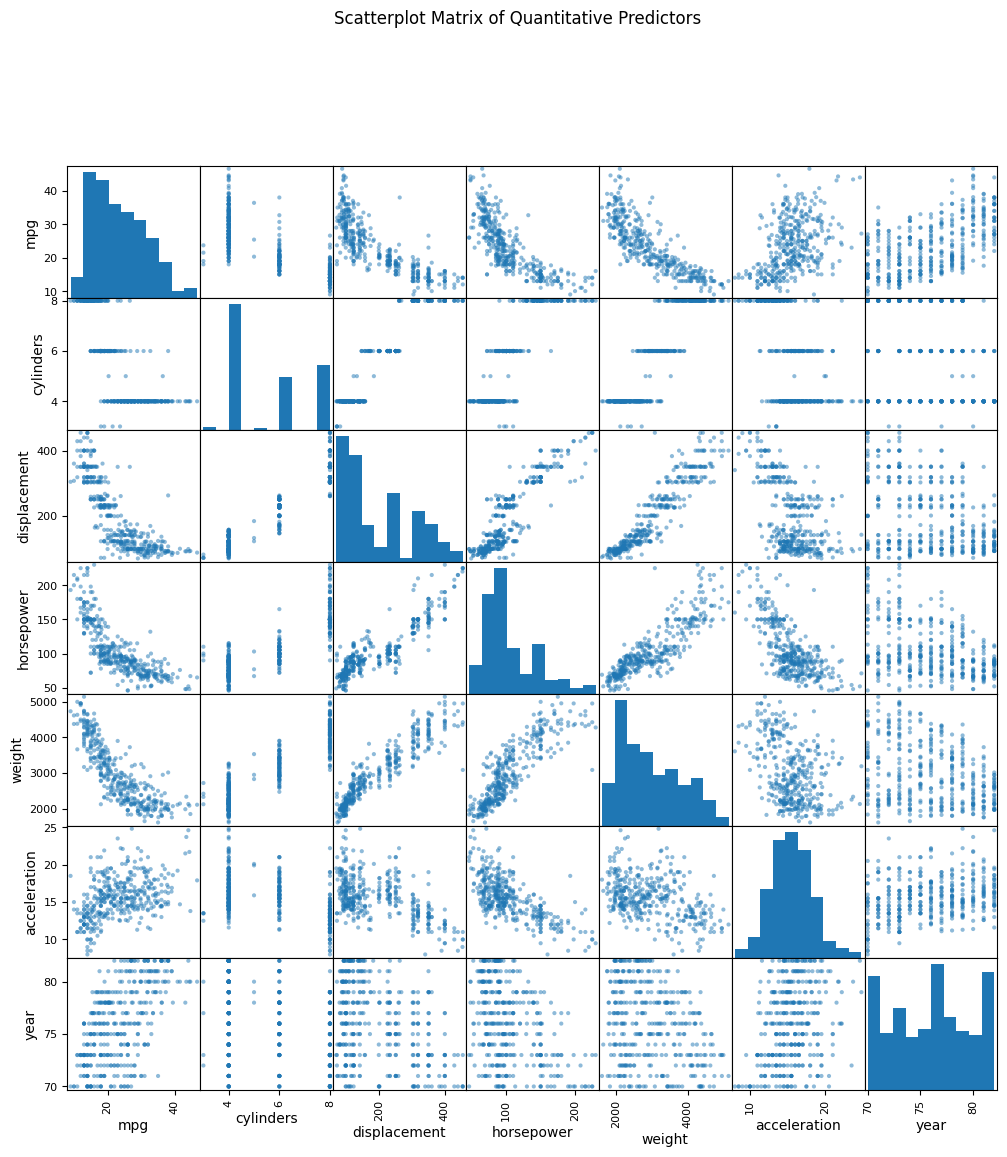

In [18]:
pd.plotting.scatter_matrix(auto[quantitative], figsize=(12, 12), diagonal='hist');
plt.suptitle('Scatterplot Matrix of Quantitative Predictors', y=1.01)
plt.show()

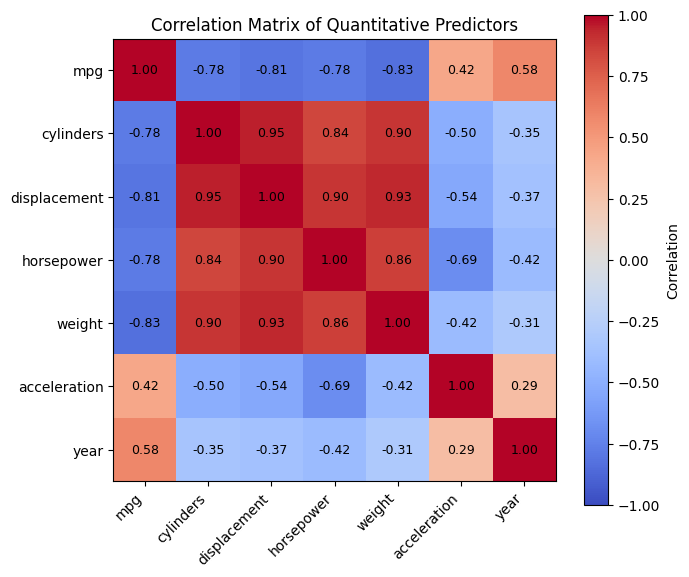

In [19]:
corr = auto[quantitative].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(quantitative)))
ax.set_yticks(range(len(quantitative)))
ax.set_xticklabels(quantitative, rotation=45, ha='right')
ax.set_yticklabels(quantitative)
for i in range(len(quantitative)):
    for j in range(len(quantitative)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                color='black', fontsize=9)
fig.colorbar(im, label='Correlation')
plt.title('Correlation Matrix of Quantitative Predictors')
plt.tight_layout()
plt.show()

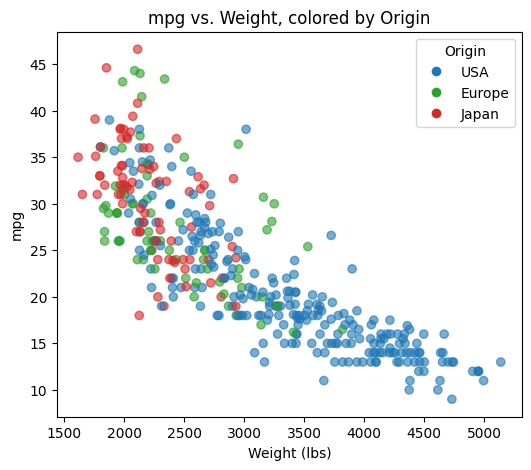

In [20]:
plt.figure(figsize=(6, 5))
colors = auto['origin'].map({1: 'tab:blue', 2: 'tab:green', 3: 'tab:red'})
plt.scatter(auto['weight'], auto['mpg'], c=colors, alpha=0.6)
plt.xlabel('Weight (lbs)')
plt.ylabel('mpg')
plt.title('mpg vs. Weight, colored by Origin')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=l, markersize=8)
           for c, l in zip(['tab:blue', 'tab:green', 'tab:red'], ['USA', 'Europe', 'Japan'])]
plt.legend(handles=handles, title='Origin')
plt.show()

/tmp/ipykernel_107/2010049226.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([auto.loc[auto['cylinders'] == c, 'mpg'] for c in sorted(auto['cylinders'].unique())],


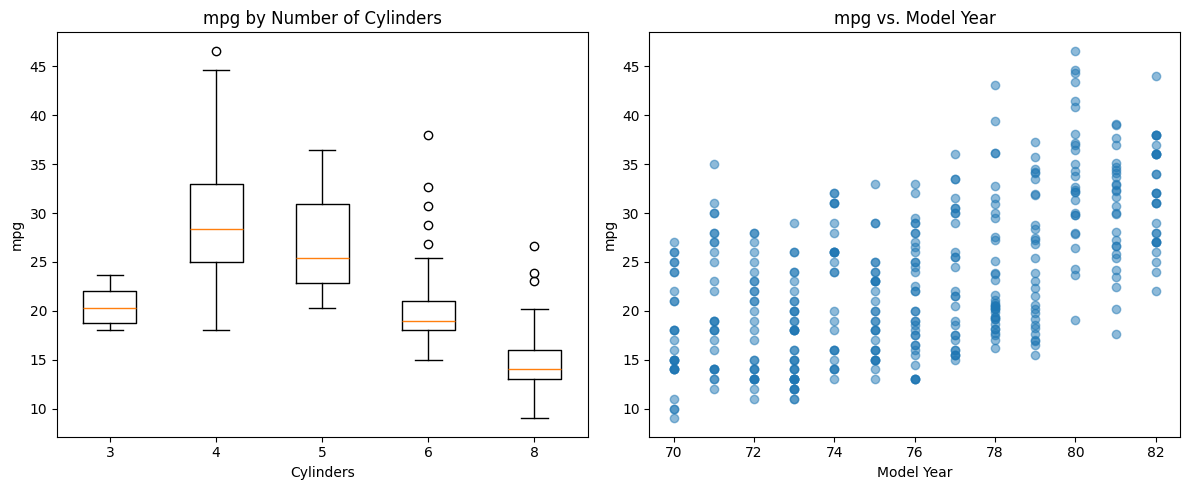

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([auto.loc[auto['cylinders'] == c, 'mpg'] for c in sorted(auto['cylinders'].unique())],
                labels=sorted(auto['cylinders'].unique()))
axes[0].set_xlabel('Cylinders')
axes[0].set_ylabel('mpg')
axes[0].set_title('mpg by Number of Cylinders')

axes[1].scatter(auto['year'], auto['mpg'], alpha=0.5)
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('mpg')
axes[1].set_title('mpg vs. Model Year')

plt.tight_layout()
plt.show()

---

# Chapter 2, Applied Exercise 10 — The `Boston` Housing Data Set

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

boston = pd.read_csv('Boston.csv', index_col=0)
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### (b) Rows, columns, and what they represent

Each **row** is a suburb (census tract) in the Boston area. Each **column**
is a measured variable for that suburb:

| Column | Meaning |
|---|---|
| `crim` | per capita crime rate by town |
| `zn` | proportion of residential land zoned for large lots (>25,000 sq ft) |
| `indus` | proportion of non-retail business acres per town |
| `chas` | Charles River dummy variable (1 if tract bounds the river, 0 otherwise) |
| `nox` | nitrogen oxide concentration (parts per 10 million) |
| `rm` | average number of rooms per dwelling |
| `age` | proportion of owner-occupied units built before 1940 |
| `dis` | weighted distance to five Boston employment centers |
| `rad` | index of accessibility to radial highways |
| `tax` | full-value property-tax rate per \$10,000 |
| `ptratio` | pupil-teacher ratio by town |
| `lstat` | percent of the population classified as lower status |
| `medv` | median value of owner-occupied homes, in \$1,000s |

In [23]:
print(f"Number of rows (suburbs): {boston.shape[0]}")
print(f"Number of columns (variables): {boston.shape[1]}")

Number of rows (suburbs): 506
Number of columns (variables): 13


### (c) Pairwise scatterplots of the predictors

A full scatterplot matrix of all 13 variables.

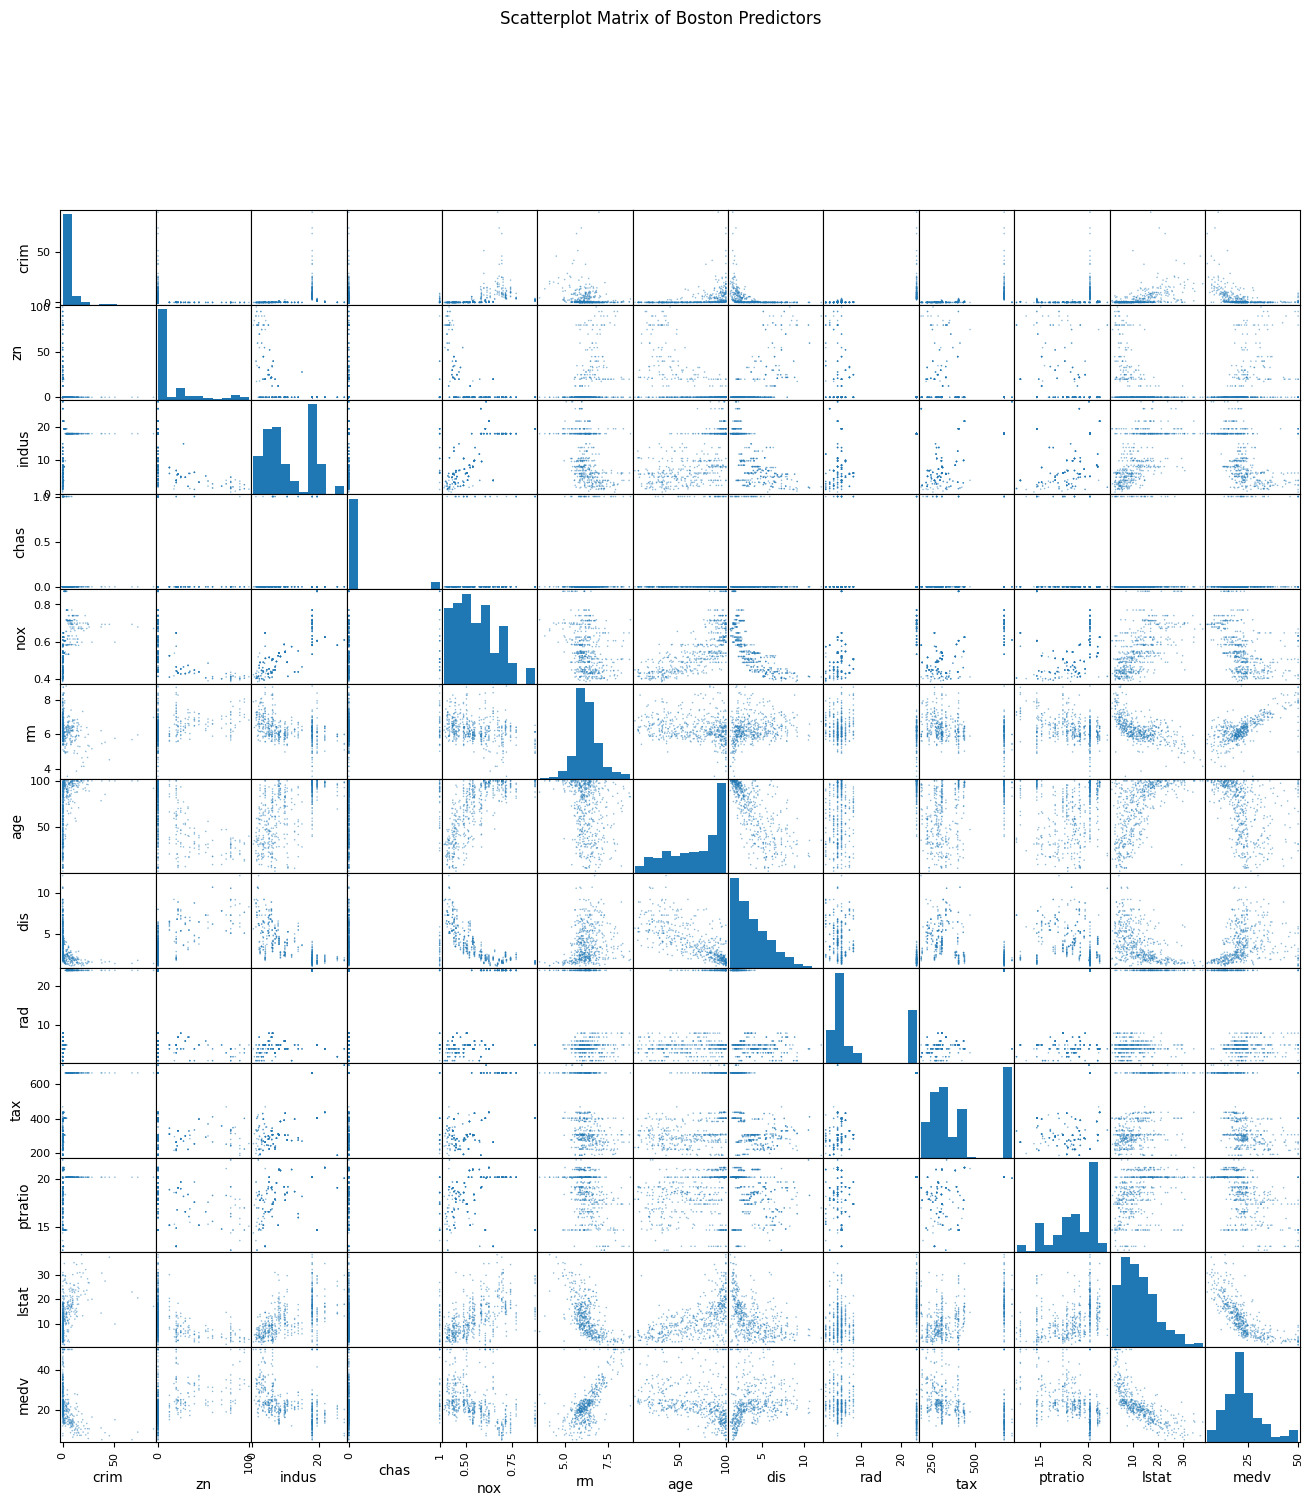

In [24]:
pd.plotting.scatter_matrix(boston, figsize=(16, 16), diagonal='hist', s=5, alpha=0.5);
plt.suptitle('Scatterplot Matrix of Boston Predictors', y=1.005)
plt.show()

In [25]:
crim_corr = boston.corr()['crim'].drop('crim').sort_values(key=abs, ascending=False)
crim_corr

rad        0.625505
tax        0.582764
lstat      0.455621
nox        0.420972
indus      0.406583
medv      -0.388305
dis       -0.379670
age        0.352734
ptratio    0.289946
rm        -0.219247
zn        -0.200469
chas      -0.055892
Name: crim, dtype: float64

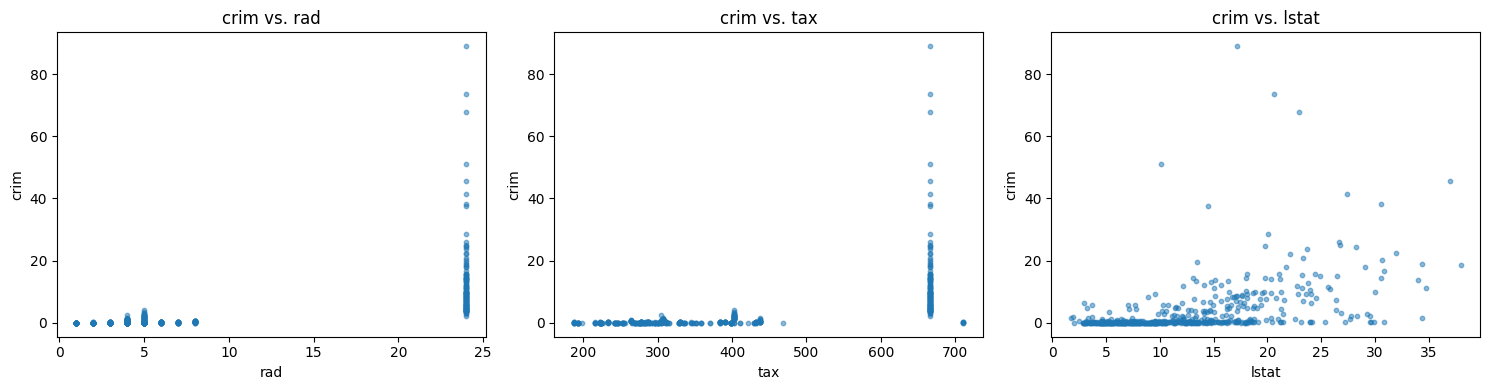

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['rad', 'tax', 'lstat']):
    ax.scatter(boston[col], boston['crim'], alpha=0.5, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('crim')
    ax.set_title(f'crim vs. {col}')
plt.tight_layout()
plt.show()

### (e) Suburbs with unusually high crime, tax, or pupil-teacher ratios; predictor ranges

In [27]:
ranges = pd.DataFrame({
    'min': boston.min(),
    'max': boston.max(),
    'range': boston.max() - boston.min()
})
ranges

,min,max,range
crim,0.00632,88.9762,88.96988
zn,0.00000,100.0000,100.00000
indus,0.46000,27.7400,27.28000
chas,0.00000,1.0000,1.00000
nox,0.38500,0.8710,0.48600
rm,3.56100,8.7800,5.21900
age,2.90000,100.0000,97.10000
dis,1.12960,12.1265,10.99690
rad,1.00000,24.0000,23.00000
tax,187.00000,711.0000,524.00000


In [28]:
print("Suburbs with the highest crime rates:")
print(boston['crim'].sort_values(ascending=False).head())

print("\nSuburbs with the highest tax rates:")
print(boston['tax'].sort_values(ascending=False).head())

print("\nSuburbs with the highest pupil-teacher ratios:")
print(boston['ptratio'].sort_values(ascending=False).head())

Suburbs with the highest crime rates:
381    88.9762
419    73.5341
406    67.9208
411    51.1358
415    45.7461
Name: crim, dtype: float64

Suburbs with the highest tax rates:
493    711
492    711
491    711
490    711
489    711
Name: tax, dtype: int64

Suburbs with the highest pupil-teacher ratios:
356    22.0
355    22.0
140    21.2
141    21.2
136    21.2
Name: ptratio, dtype: float64


### (f) Suburbs that bound the Charles River

In [29]:
charles_river_count = (boston['chas'] == 1).sum()
print(f"Suburbs bounding the Charles River: {charles_river_count}")

Suburbs bounding the Charles River: 35


### (g) Median pupil-teacher ratio

In [30]:
median_ptratio = boston['ptratio'].median()
print(f"Median pupil-teacher ratio: {median_ptratio}")

Median pupil-teacher ratio: 19.05


### (h) Suburb with the lowest median value of owner-occupied homes

In [31]:
lowest_medv_idx = boston['medv'].idxmin()
lowest_medv_row = boston.loc[[lowest_medv_idx]]
lowest_medv_row

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
399,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,30.59,5.0


In [32]:
comparison = pd.DataFrame({
    'suburb_value': boston.loc[lowest_medv_idx],
    'overall_min': boston.min(),
    'overall_max': boston.max(),
    'overall_median': boston.median()
})
comparison

,suburb_value,overall_min,overall_max,overall_median
crim,38.3518,0.00632,88.9762,0.25651
zn,0.0000,0.00000,100.0000,0.00000
indus,18.1000,0.46000,27.7400,9.69000
chas,0.0000,0.00000,1.0000,0.00000
nox,0.6930,0.38500,0.8710,0.53800
rm,5.4530,3.56100,8.7800,6.20850
age,100.0000,2.90000,100.0000,77.50000
dis,1.4896,1.12960,12.1265,3.20745
rad,24.0000,1.00000,24.0000,5.00000
tax,666.0000,187.00000,711.0000,330.00000


### (i) Suburbs averaging more than 7 or 8 rooms per dwelling

In [33]:
more_than_7 = (boston['rm'] > 7).sum()
more_than_8 = (boston['rm'] > 8).sum()
print(f"Suburbs averaging more than 7 rooms per dwelling: {more_than_7}")
print(f"Suburbs averaging more than 8 rooms per dwelling: {more_than_8}")

Suburbs averaging more than 7 rooms per dwelling: 64
Suburbs averaging more than 8 rooms per dwelling: 13


In [34]:
boston[boston['rm'] > 8]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
98,0.12083,0.0,2.89,0,0.4450,8.069,76.0,3.4952,2,276,18.0,4.21,38.7
164,1.51902,0.0,19.58,1,0.6050,8.375,93.9,2.1620,5,403,14.7,3.32,50.0
205,0.02009,95.0,2.68,0,0.4161,8.034,31.9,5.1180,4,224,14.7,2.88,50.0
225,0.31533,0.0,6.20,0,0.5040,8.266,78.3,2.8944,8,307,17.4,4.14,44.8
226,0.52693,0.0,6.20,0,0.5040,8.725,83.0,2.8944,8,307,17.4,4.63,50.0
227,0.38214,0.0,6.20,0,0.5040,8.040,86.5,3.2157,8,307,17.4,3.13,37.6
233,0.57529,0.0,6.20,0,0.5070,8.337,73.3,3.8384,8,307,17.4,2.47,41.7
234,0.33147,0.0,6.20,0,0.5070,8.247,70.4,3.6519,8,307,17.4,3.95,48.3
254,0.36894,22.0,5.86,0,0.4310,8.259,8.4,8.9067,7,330,19.1,3.54,42.8
258,0.61154,20.0,3.97,0,0.6470,8.704,86.9,1.8010,5,264,13.0,5.12,50.0
